In [45]:
import os
import pysam
import pickle
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as patches
import pylab
import seaborn as sns
from scipy.stats import ks_2samp

In [2]:
#hpv gene site
pave_hpvDic = {'E1': [['865', '2814']],
 'E2': [['2756', '3853']],
 'E5_ALPHA': [['3850', '4101']],
 'E6': [['104', '559']],
 'E7': [['562', '858']],
 'L1': [['5639', '7156']],
 'L2': [['4237', '5658']],
 'E1^E4': [['865', '880'], ['3358', '3620']],
 'E1BS': [['7898', '7906'], ['1', '11']],
 'E2BS': [['7860', '7871']],
 'URR': [['7157', '7906'], ['1', '103']]}

In [3]:
#microhomology
#get blockList
def getBlock(bam):
    blockList = {}
    for read in sam.fetch():
    #record the matched region, use each contig as axis
        
        start = read.pos
        contig = read.qname
        blocks = read.get_blocks()
        cigar = read.cigartuples
        length = read.infer_read_length()
        #if start with clip
        if cigar[0][0] == 4 or cigar[0][0] == 5:
            for block in blocks:
                if not read.is_reverse:
                    if contig not in blockList:
                        blockList[contig] = [[block[0]-start+ cigar[0][1] + 1,block[1]-start+ cigar[0][1]]]
                    else:
                        blockList[contig].append([block[0]-start+ cigar[0][1] + 1,block[1]-start+ cigar[0][1]])
                else:
                    if contig not in blockList:
                        blockList[contig] = [[length-(block[1]-start+ cigar[0][1]) + 1,length-(block[0]-start+ cigar[0][1] + 1) + 1]]
                    else:
                        blockList[contig].append([length-(block[1]-start+ cigar[0][1]) + 1,length-(block[0]-start+ cigar[0][1] + 1) + 1])
        elif cigar[0][0] == 0:
            for block in blocks:
                if not read.is_reverse:
                    if contig not in blockList:
                        blockList[contig] = [[block[0]-start + 1,block[1]-start]]
                    else:
                        blockList[contig].append([block[0]-start + 1,block[1]-start])
                else:
                    if contig not in blockList:
                        blockList[contig] = [[length-(block[1]-start) + 1,length-(block[0]-start + 1) + 1]]
                    else:
                        blockList[contig].append([length-(block[1]-start) + 1,length-(block[0]-start + 1) + 1])
            #print(contig,read.get_forward_sequence(),block,blockList)
    return blockList

In [4]:
def getBlock2(bam):
    sam = pysam.AlignmentFile(bam, "rb")
    blockList = {}#blockList[contig] = [start,end,cigarString]
    for read in sam.fetch():
        start = read.pos
        contig = read.qname
        blocks = read.get_blocks()
        cigar = read.cigartuples
        length = read.infer_read_length()
        #if start with clip
        start = 0
        end = 0
        for eachSlot in cigar:
            end += eachSlot[1]
            if not read.is_reverse:
                if contig not in blockList:
                    blockList[contig] = [[start,end,eachSlot[0]]]
                else:
                    blockList[contig].append([start,end,eachSlot[0]])
            else:
                if contig not in blockList:
                    blockList[contig] = [[length-end + 1,length-start + 1,eachSlot[0]]]
                else:
                    blockList[contig].append([length-end + 1,length-start + 1,eachSlot[0]])
            start += eachSlot[1]
    newBlockList = {}
    for contig in blockList:
        for each in  blockList[contig]:
            if each[2] == 0:
                if contig not in newBlockList:
                    newBlockList[contig] = [[each[0],each[1]]]
                else:
                    newBlockList[contig].append([each[0],each[1]])
                
    return newBlockList
                

In [5]:
#count overlap
def countOverlap(selectedContig,genomeBlock,hpvBlock):
    scoreDic = {}
    for each in selectedContig:
        score = 0
        overlap = False
        cleanEnd = False
        for slot1 in genomeBlock[each]:
            start1 = slot1[0]
            end1 = slot1[1]
            for slot2 in hpvBlock[each]:
                start2 = slot2[0]
                end2 = slot2[1]
                # overlap
                oldScore = score
                if start2 <= end1 and start1 <= end2:
                    overlap = True
                    if end1-start2 > end2-start1:
                        newScore = end2-start1 + 1
                    else:
                        newScore = end1-start2 + 1
                    if newScore > oldScore:
                        score = newScore
        #clean end
        if overlap == False:
            score = 0
            for slot1 in genomeBlock[each]:
                start1 = slot1[0]
                end1 = slot1[1]
                for slot2 in hpvBlock[each]:
                    start2 = slot2[0]
                    end2 = slot2[1]
                    #clean end
                    if start2 == end1 + 1 or start1 == end2 + 1:
                        cleanEnd = True
                        score += 0
            #gap
            if overlap == False and cleanEnd == False:
                score = 0
                for slot1 in genomeBlock[each]:
                    start1 = slot1[0]
                    end1 = slot1[1]
                    for slot2 in hpvBlock[each]:
                        start2 = slot2[0]
                        end2 = slot2[1]
                        #gap
                        oldScore = score
                        if end1 < start2 or end2 < start1:
                            if end1 < start2:
                                newScore2 = -(start2 - end1 - 1)
                            elif end2 < start1:
                                newScore2 = -(start1 - end2 - 1)
                            if newScore2 > oldScore and oldScore != 0:
                                score = newScore2
                                #print(newScore2)
                            elif oldScore == 0:
                                score = newScore2
        #filter score > 100 or <-100
#         if score < 100 and score > -100:
        scoreDic[each] = score
    return(scoreDic)

In [6]:
#sample study here
sup_3=pd.read_csv('../sup_3/Sup_3_final.csv')

In [7]:
sup_3

,Unnamed: 0,ID,SeqID_Tumor,SeqID_Normal,Multiple samples? (0/1),Sample label (a/b/c),RNAseq (0/1),PrimaryRM,Site,p16,...,At least 1 integration is a type2 structure,HPV integration type,HPV integration,HPV integration breakpoints on HPV genome,Total # Host Genes with integration,Host Genes with integration,Integrated in at least 1 human gene,Integrated in at least 1 human cancer gene (COSMIC Teir1/2),Integrated in at least 1 human cancer gene (COSMIC Teir1/2); Gene Name,# of E2 Breakpoints
0,0,3968,83026,83025,0,NaN,1,RM,OP,P,...,0.0,Type1,chr3:54562145;chr12:91944711;chr3:93470774;chr...,"893;4700,1149;6791,7405;4184;6584;4925;6791,74...",8,"CACNA2D3;;;;COL14A1;ENST00000534275,DLG2;;LINC...",True,False,;;;;;;;;,0
1,1,3983,83030,83029,0,NaN,1,P,OP,P,...,0.0,Type1,chr8:3990025;chr8:3866216;chr14:106781925;chr1...,2128;3233;2249;4357;3916;2480;4414;2480;1347,3,CSMD1;CSMD1;;SORCS3;;;LINC02346;;,True,False,;;;;;;;;,1
2,2,3996,83034,83033,0,NaN,0,RM,OP,P,...,0.0,Type1,chr11:56835917;chr6:34844401;chr8:100385068;ch...,"6989;1434;5453,1937;1433",6,";UHRF1BP1;ENST00000657736,ENST00000654832,ENST...",True,False,;;;,0
3,3,4008,83044,83043,0,NaN,1,P,OP,P,...,0.0,Type1,chr10:31032491;chr7:42649195;chr9:68582624;chr...,996;6874;6264;7239;5778;7116;3913;5060;972;980...,7,";;TMEM252-DT;;;;HS3ST5,HDAC2-AS2;OR52A1;;;DYSF...",True,True,;;;;;;;;;;;;MSI2;;,2
4,4,4010,83048,83047,0,NaN,0,P,OP,N,...,0.0,Type1,chr17:82263199;chr3:78853185;chr11:21407740;ch...,2159;2110;1400;1344,4,CSNK1D;ROBO1;NELL1;FUT8,True,False,;;;,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,178,VA74,6670-CB-75,6670-CB-76,0,NaN,0,P,OP,P,...,0.0,Type1,chr4:137958671;chr11:27409717;chr7:2092566;chr...,2972;1421;4667;5671;7161;5663;4399;940;5567;59...,28,"ENST00000655176;LGR4;MAD1L1,ENST00000651235;;D...",True,False,;;;;;;;;;;;;;;;;;;;,3
179,179,5037,6670-CB-77,6670-CB-78,0,NaN,0,P,OP,P,...,1.0,Type2,chr12:25084502;chr9:116978499;chr5:7371447;chr...,7270;7239;2178;2178;1573;4395;973;7270;941;537...,215,IRAG2;ASTN2;ENST00000513219;ENST00000513219;EW...,True,True,;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;LEF1;;;;;;;;;;;;...,18
180,180,4854,6670-CB-83,NaN,1,RM 6670-CB-80,0,P,OP,P,...,0.0,Type1,chr1:77367484;chr4:28657339;chr6:56637091;chr1...,4204;5316;4184;888;7561;1278;4184;465;6074;925...,250,"AK5;;DST;ENST00000548576,LINC02388,ENST0000054...",True,True,;;;;;;;;;;;;;;DCC;;;;;;;;;;;;;;;;;;;;;;;;;DNM2...,12
181,181,4945,6670-CB-84,NaN,1,RM 6670-CB-81/82,0,P,OP,P,...,0.0,Type1,chr6:119283579;chr3:30681172;chr20:48440466,903;3297;3506,2,MAN1A1;TGFBR2;,True,True,;TGFBR2;,2


In [26]:
#MEC
def check_mh_score(sample_list,path,output_dir):
    MEC_scoreList = []
    sample_processed = []
    for sample in sample_list:
        resPath = f'{path}/Sample_{sample}/call_fusion_virus/'
        finalRes = f'{path}/Sample_{sample}/call_fusion_virus/filteredSelectedContig.pickle'
        with open(finalRes,'rb') as inputFile:
            resDic = pickle.load(inputFile)
        for each in resDic:
            if os.path.isdir(resPath + each):
                alignGenome = f'{resPath}/{each}/{each}.contigToGenome.sort.bam'
                alignHPV = f'{resPath}/{each}/{each}.contigToVirus.sort.bam'
                genomeBlock = getBlock2(alignGenome)
                hpvBlock = getBlock2(alignHPV)
                #selected Contig
                selectedContig = []
                for eachSlot in resDic[each]:
                    selectedContig.append(eachSlot[0])
                #count overlap bp
                scoreDic = countOverlap(selectedContig,genomeBlock,hpvBlock)
                for contig in scoreDic:
                    MEC_scoreList.append(scoreDic[contig])
                    print(scoreDic[contig])
                    sample_processed.append(sample)
    pd.DataFrame(MEC_scoreList).to_csv(output_dir)
    return MEC_scoreList,sample_processed


In [20]:
#type1
type1_list = sup_3[sup_3['HPV integration type'] == 'Type1']['SeqID_Tumor']

In [21]:
path = '/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res/'

In [27]:
type_1_score,sample_done_type1= check_mh_score(type1_list,path,'type_1_mh_score.csv')

[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83026/call_fusion_virus//3.54562145/3.54562145.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83026/call_fusion_virus//12.91944711/12.91944711.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83026/call_fusion_virus//3.93470774/3.93470774.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83026/call_fusion_virus//16.25541381/16.25541381.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83026/call_fusion_vir

8
-15
4
4
16
26
2
3
4
16
6
23
2
-24
6
25
9
1
1
1
14
8
-8
2
6
-2


[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83030/call_fusion_virus//12.76962150/12.76962150.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83030/call_fusion_virus//3.93470586/3.93470586.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83030/call_fusion_virus//15.26038251/15.26038251.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83030/call_fusion_virus//3.93470784/3.93470784.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83030/call_fusion_vir

0
2
19
9
3
5
11
10


[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83044/call_fusion_virus//7.42649195/7.42649195.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83044/call_fusion_virus//9.68582624/9.68582624.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83044/call_fusion_virus//2.8593725/2.8593725.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83044/call_fusion_virus//2.186995465/2.186995465.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83044/call_fusion_virus//

...

[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-83/call_fusion_virus//21.37336773/21.37336773.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-83/call_fusion_virus//14.20164342/14.20164342.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-83/call_fusion_virus//9.102007521/9.102007521.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-83/call_fusion_virus//13.45436836/13.45436836.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Samp

5
37
7
7
9
3
32
28
7
10
16


[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-83/call_fusion_virus//21.32289225/21.32289225.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-83/call_fusion_virus//15.55573358/15.55573358.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-83/call_fusion_virus//10.33182807/10.33182807.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-83/call_fusion_virus//19.51916385/19.51916385.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Samp

4
6
9
-1
5


[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-84/call_fusion_virus//3.30681172/3.30681172.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-84/call_fusion_virus//20.48440466/20.48440466.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-85/call_fusion_virus//5.118479649/5.118479649.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-85/call_fusion_virus//10.104361089/10.104361089.contigToGenome.sort.bam.bai


In [24]:
#type2
type2_list = sup_3[sup_3['HPV integration type'] == 'Type2']['SeqID_Tumor']

In [32]:
type_2_score,sample_done_type2 = check_mh_score(type2_list,path,'type_2_mh_score.csv')

[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_virus//9.5485117/9.5485117.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_virus//Y.19569045/Y.19569045.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_virus//5.86944580/5.86944580.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_virus//12.90074608/12.90074608.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_virus//

4
5
5
4
3
2
4
4
3
1


[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_virus//3.93470653/3.93470653.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_virus//9.5477245/9.5477245.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_virus//10.104317618/10.104317618.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_virus//7.124695922/7.124695922.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_vir

1
-10
2
6
1
-10
2
2
-14
8
0
5
6


[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_virus//1.168831536/1.168831536.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_virus//9.5445702/9.5445702.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_virus//1.222850303/1.222850303.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_virus//9.5441465/9.5441465.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_83062/call_fusion_virus//

...

[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-77/call_fusion_virus//15.50184008/15.50184008.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-77/call_fusion_virus//15.97576043/15.97576043.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-77/call_fusion_virus//11.86877880/11.86877880.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-77/call_fusion_virus//4.104061110/4.104061110.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Samp

12
12
9
9
5
6
17
5
7
-4
8


[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-77/call_fusion_virus//6.55637740/6.55637740.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-77/call_fusion_virus//7.79363868/7.79363868.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-77/call_fusion_virus//3.110091219/3.110091219.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-77/call_fusion_virus//7.108633152/7.108633152.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6

7
7
6
11
13
-13
7


[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-77/call_fusion_virus//8.127731906/8.127731906.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-77/call_fusion_virus//2.37027980/2.37027980.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-77/call_fusion_virus//8.103870394/8.103870394.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6670-CB-77/call_fusion_virus//8.40742770/8.40742770.contigToGenome.sort.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res//Sample_6

In [29]:
len(set(sample_done_type1))

103

In [30]:
len(type1_list)

103

In [33]:
len(set(sample_done_type2))

52

In [34]:
len(type2_list)

52

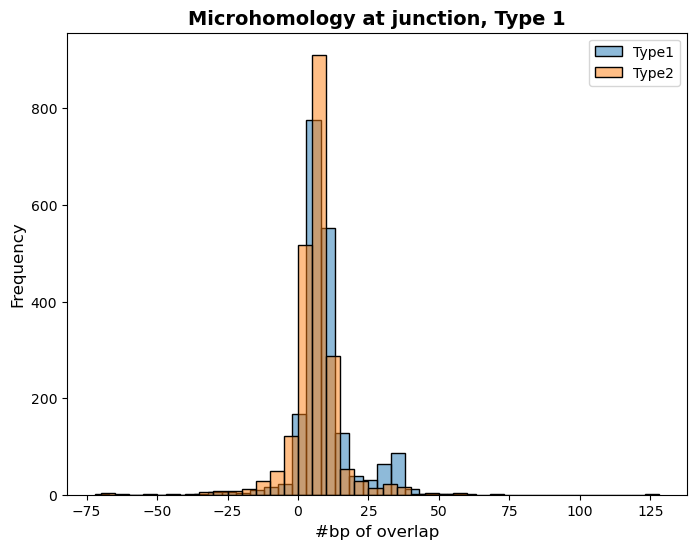

<Figure size 640x480 with 0 Axes>

In [44]:
#plot for type1
# Set Seaborn style
#sns.set_style("whitegrid")

# Create histogram with KDE
plt.figure(figsize=(8, 6))
sns.histplot(type_1_score, binwidth=5, edgecolor="black", alpha=0.5,label = 'Type1')
sns.histplot(type_2_score, binwidth=5, edgecolor="black", alpha=0.5,label = 'Type2')

# Labels and title
plt.xlabel("#bp of overlap", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Microhomology at junction, Type 1", fontsize=14, fontweight="bold")
plt.legend()
# Show plot
plt.show()
plt.savefig("microhomology.pdf")


In [48]:
#test to test two distribution
# KS Test
ks_stat, p_value = ks_2samp(type_1_score, type_2_score)

print(f"KS Statistic: {ks_stat}, P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("Distributions are significantly different (Reject H0)")
else:
    print("No significant difference (Fail to reject H0)")



KS Statistic: 0.15555835619146466, P-value: 1.0908683403504029e-21
Distributions are significantly different (Reject H0)
